In [2]:
import matplotlib
matplotlib.use('Agg')

import os
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

params = {
   'axes.labelsize': 14,
   'font.size': 14,
   'font.family': ' DejaVu Sans',
   'legend.fontsize': 20,
   'xtick.labelsize': 20,
   'ytick.labelsize': 20,
   'axes.labelsize': 25,
   'axes.titlesize': 25,
   'text.usetex': False,
   'figure.figsize': [12, 12]
}
matplotlib.rcParams.update(params)


import ase.io
from ase.io.trajectory import Trajectory
from ase.io import extxyz
from ase.calculators.emt import EMT
from ase.build import fcc100, add_adsorbate, molecule
from ase.constraints import FixAtoms
from ase.optimize import LBFGS
from ase.visualize.plot import plot_atoms
from ase import Atoms
from IPython.display import Image

import sys
sys.path.append(r"D:\Train_thử\fairchem-tio2-s2ef")
from ocpmodels.datasets import LmdbDataset

In [3]:
videos_dir = "videos/"
os.makedirs(videos_dir, exist_ok=True)

config = {
    "num_procs": 1,
    "fps": 30,
}

## OC22 Dataset Visulization

In [4]:
lmdb_path = r"D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\tio2_filtered\train"


dataset = LmdbDataset({"src": lmdb_path})
data = dataset[0]

### Convert file .lmdb to .extxyz

In [5]:
from ase.io import extxyz
from ase import Atoms
from tqdm import tqdm
import numpy as np
import torch

def convert_data_to_ase(data):
    """Manually convert PyG Data object to ASE Atoms"""
    
    # Extract positions and atomic numbers
    positions = data.pos.cpu().numpy() if torch.is_tensor(data.pos) else np.array(data.pos)
    atomic_numbers = data.atomic_numbers.cpu().numpy() if torch.is_tensor(data.atomic_numbers) else np.array(data.atomic_numbers)
    
    # Ensure correct shapes
    if positions.ndim == 1:
        positions = positions.reshape(-1, 3)
    if atomic_numbers.ndim > 1:
        atomic_numbers = atomic_numbers.flatten()
    
    # Create atoms object
    atoms = Atoms(
        numbers=atomic_numbers,
        positions=positions
    )
    
    # Add cell if available
    if hasattr(data, 'cell') and data.cell is not None:
        cell = data.cell.cpu().numpy() if torch.is_tensor(data.cell) else np.array(data.cell)
        
        # Handle different cell formats
        if cell.ndim == 1:
            if len(cell) == 3:
                cell = np.diag(cell)
        
        if cell.shape == (3, 3):
            atoms.set_cell(cell)
            atoms.set_pbc(True)
    
    # Add tags if available
    if hasattr(data, 'tags') and data.tags is not None:
        tags = data.tags.cpu().numpy() if torch.is_tensor(data.tags) else np.array(data.tags)
        atoms.set_tags(tags.flatten())
    
    # Add fixed atoms constraint if available
    if hasattr(data, 'fixed') and data.fixed is not None:
        fixed = data.fixed.cpu().numpy() if torch.is_tensor(data.fixed) else np.array(data.fixed)
        fixed = fixed.flatten().astype(bool)
        if fixed.any():
            from ase.constraints import FixAtoms
            atoms.set_constraint(FixAtoms(mask=fixed))
    
    return atoms


def lmdb_to_extxyz(lmdb_path, output_path, max_structures=None):
    """Convert file LMDB to extxyz"""
    
    print(f"Loading dataset from {lmdb_path}...")
    dataset = LmdbDataset({"src": lmdb_path})
    
    structures = []
    errors = []
    num_samples = min(len(dataset), max_structures) if max_structures else len(dataset)
    
    print(f"Processing {num_samples} structures...")
    
    for i in tqdm(range(num_samples)):
        try:
            data = dataset[i]
            atoms = convert_data_to_ase(data)
            structures.append(atoms)
        except Exception as e:
            errors.append((i, str(e)))
            continue
    
    print(f"Successfully converted: {len(structures)}/{num_samples} structures")
    print(f"Errors: {len(errors)}")
    print(f"{'='*50}")
    
    if errors:
        print(f"\nShowing first 10 errors:")
        for idx, err in errors[:10]:
            print(f"  Index {idx}: {err}")
    
    if structures:
        print(f"\nWriting {len(structures)} structures to {output_path}...")
        columns = ['symbols', 'positions']
        
        with open(output_path, 'w') as f:
            extxyz.write_xyz(f, structures, columns=columns)
        
        print(f"✓ Done! Saved to {output_path}")
        return structures
    else:
        print("✗ No structures to save!")
        return None


# Usage
lmdb_path = r"D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\tio2_filtered\train"  # TiO2 filtered training set (after running filtering script)
output_path = "data/oc22_structures.extxyz"

# Test with 100 structures first
structures = lmdb_to_extxyz(lmdb_path, output_path, max_structures=100)

# Run on all
# structures = lmdb_to_extxyz(lmdb_path, output_path)

Loading dataset from D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\tio2_filtered\train...
Processing 100 structures...


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 1112.98it/s]

Successfully converted: 100/100 structures
Errors: 0

Writing 100 structures to data/oc22_structures.extxyz...
✓ Done! Saved to data/oc22_structures.extxyz


### Visualize

Visualizing 2 related structures


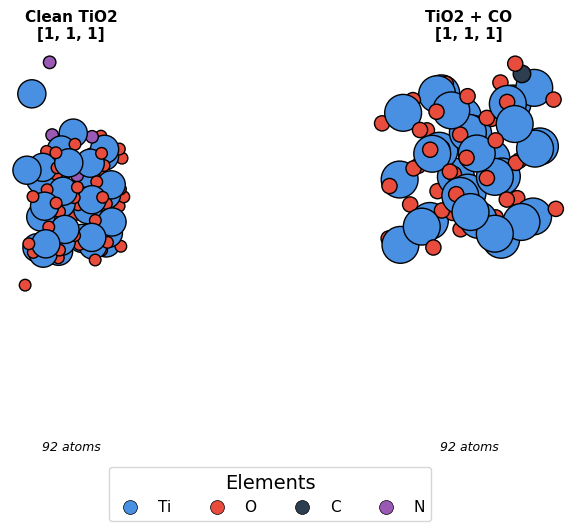

✓ Saved to 'tio2_surface_variants.png'


In [8]:
import json
import ase.io
from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Load data
with open(r'D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\metadata\tio2_data_mapping.json', 'r') as f:
    metadata = json.load(f)

structures = ase.io.read("data/oc22_structures.extxyz", ":")

# Distinct colors
element_colors = {
    'Ti': '#4A90E2',
    'O': '#E74C3C',
    'C': '#2C3E50',
    'H': '#ECF0F1',
    'N': '#9B59B6',
}

def get_atom_colors(atoms):
    """Get colors for atoms based on element type"""
    symbols = atoms.get_chemical_symbols()
    colors = [element_colors.get(symbol, '#95A5A6') for symbol in symbols]
    return colors

# Find related structures of TiO2
target_clean_sid = "3589"   # 36509 , 3148 , 3589

related_sids = [target_clean_sid]

for sid, info in metadata.items():
    if info.get('slab_sid') == int(target_clean_sid):
        related_sids.append(sid)

print(f"Visualizing {len(related_sids)} related structures")

# Create figure
n_plots = min(len(related_sids), 4)
fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
if n_plots == 1:
    axes = [axes]

# Plot each structure
for idx, sid in enumerate(related_sids[:n_plots]):
    info = metadata[sid]
    struct_idx = list(metadata.keys()).index(sid)
    atoms = structures[struct_idx]
    
    # Get consistent colors
    colors = get_atom_colors(atoms)
    
    # Setup axis
    axes[idx].axis('off')
    
    # Title with composition info
    if info['nads'] == 0:
        title = f"Clean TiO2\n{info['miller_index']}"
    else:
        title = f"TiO2 + {info['ads_symbols']}\n{info['miller_index']}"
    
    axes[idx].set_title(title, fontsize=11, fontweight='bold')
    
    # Plot with colors
    plot_atoms(atoms, axes[idx], radii=0.85, rotation=("-75x, 45y, 10z"), colors=colors)
    
    # Add atom count
    n_atoms = len(atoms)
    axes[idx].text(0.5, -0.1, f'{n_atoms} atoms', 
                   transform=axes[idx].transAxes,
                   ha='center', fontsize=9, style='italic')

# Create legend
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

legend_elements = []
for element, color in element_colors.items():
    appears = False
    for sid in related_sids[:n_plots]:
        struct_idx = list(metadata.keys()).index(sid)
        if element in structures[struct_idx].get_chemical_symbols():
            appears = True
            break
    
    if appears:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=color, markersize=10, 
                   label=element, markeredgecolor='black', markeredgewidth=0.5)
        )

fig.legend(handles=legend_elements, loc='lower center', 
           bbox_to_anchor=(0.5, -0.08), ncol=len(legend_elements), 
           frameon=True, fontsize=11, title='Elements')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig("tio2_surface_variants.png", dpi=200, bbox_inches='tight')
plt.show()

print("✓ Saved to 'tio2_surface_variants.png'")

MovieWriter ffmpeg unavailable; using Pillow instead.


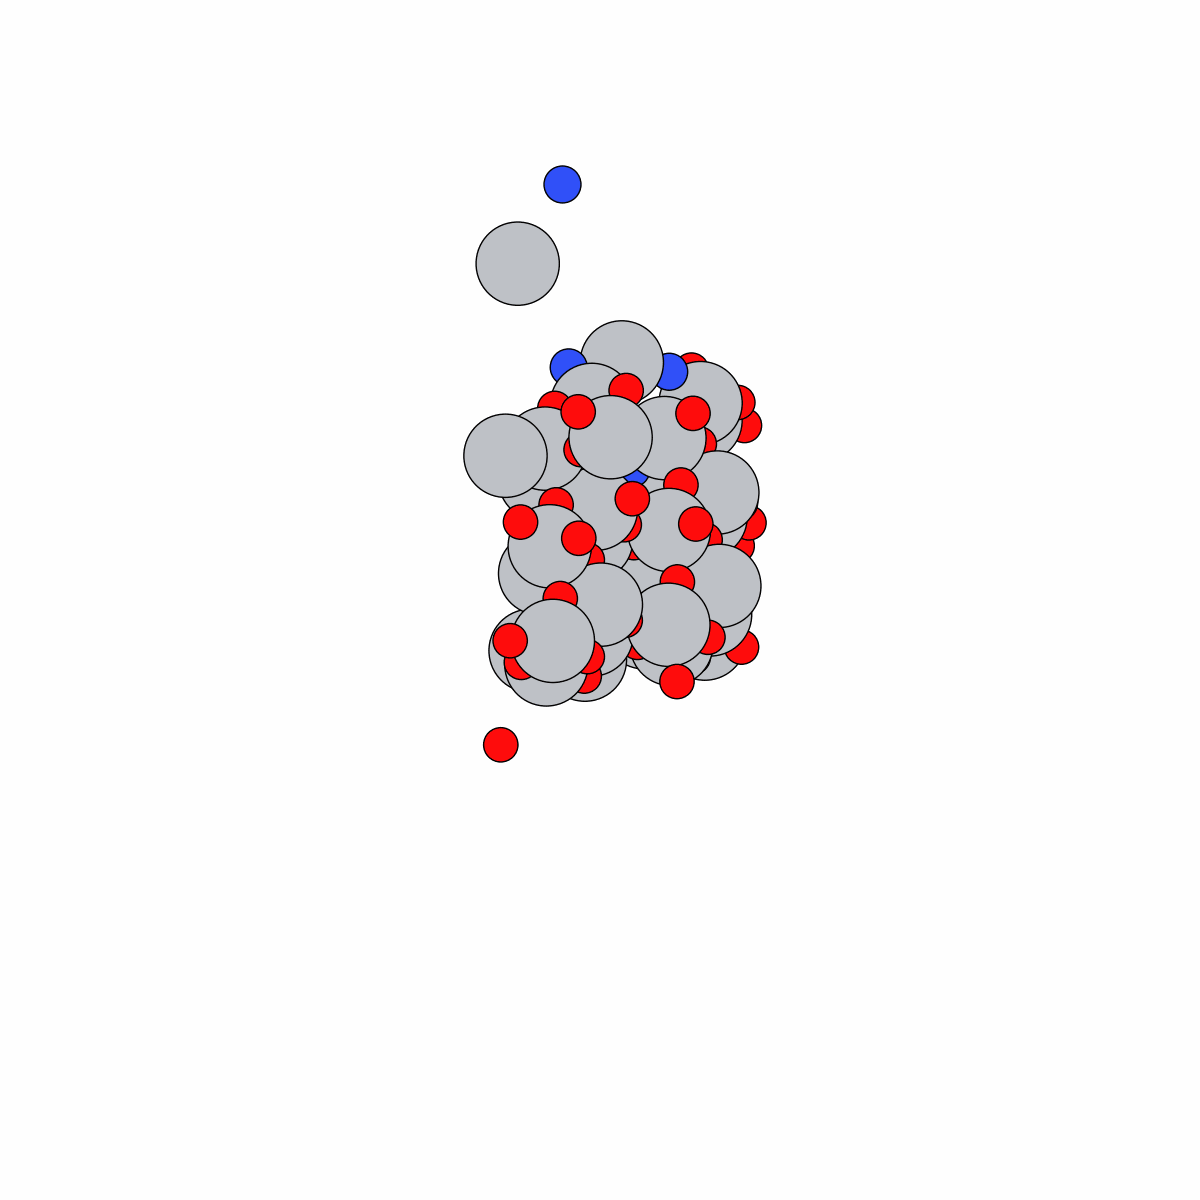

In [9]:
videos_dir = "videos/"
os.makedirs(videos_dir, exist_ok=True)

identifier = "oc22_structures.extxyz"
traj = ase.io.read("data/%s" % identifier, index=":")

ase.io.write(os.path.join(videos_dir, identifier + ".gif"),
             traj,
             interval=1,
             rotation=("-75x, 45y, 10z"))
plt.close()
Image(open(os.path.join(videos_dir, identifier + ".gif"),'rb').read())